/tmp/ipykernel_8637/1709201664.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=df, x='Model', y='R2', palette='magma', width=0.4)


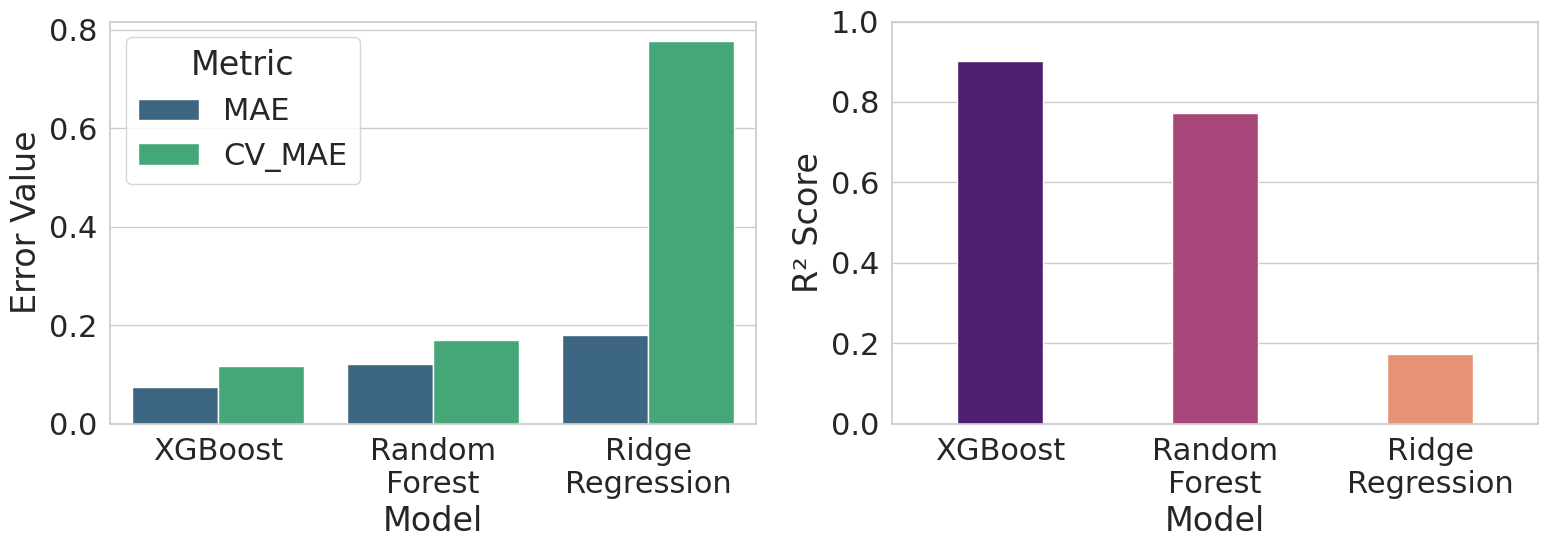

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Recreate the DataFrame from image_89c632.png
data = {
    'Model': ['XGBoost', 'Random\nForest', 'Ridge\nRegression'],
    'MAE': [0.074238, 0.121985, 0.180625],
    'R2': [0.901239, 0.772691, 0.173170],
    'CV_MAE': [0.117101, 0.169895, 0.777821]
}

df = pd.DataFrame(data)

# 2. Set the visual style
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=2)

# 3. Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Error Metrics (MAE vs CV_MAE)
# We "melt" the dataframe to make it compatible with seaborn's grouping (hue)
df_melted = df.melt(id_vars='Model', value_vars=['MAE', 'CV_MAE'], var_name='Metric', value_name='Error Value')

sns.barplot(ax=axes[0], data=df_melted, x='Model', y='Error Value', hue='Metric', palette='viridis')
#axes[0].set_title('Comparison of Error Metrics (Lower is Better)')

# Subplot 2: R-Squared Scores
sns.barplot(ax=axes[1], data=df, x='Model', y='R2', palette='magma', width=0.4)
#axes[1].set_title('Comparison of R² Scores (Higher is Better)')
axes[1].set_ylabel('R² Score')
axes[1].set_ylim(0, 1) # R2 usually stays within 0-1 for valid models

# 4. Final layout adjustments
plt.tight_layout()
plt.show()